In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/customer_data.csv")

df.head()

,name,age,gender,education,income,country,purchase_frequency,annual_spending
0,Teresa Williams MD,42,Female,High School,53936,Slovenia,0.9,13227.120
1,Christine Myers,49,Female,Master,82468,Aruba,0.6,12674.040
2,Dwayne Moreno,55,Male,Bachelor,56941,Cyprus,0.3,5354.115
3,Amy Norton,24,Female,Bachelor,60651,Palau,0.2,2606.510
4,Tonya Adams,64,Male,Master,81884,Zambia,0.9,18984.780


In [2]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(1000, 8)

Column Names:
['name', 'age', 'gender', 'education', 'income', 'country', 'purchase_frequency', 'annual_spending']

Data Types:
name                      str
age                     int64
gender                    str
education                 str
income                  int64
country                   str
purchase_frequency    float64
annual_spending       float64
dtype: object


In [3]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:")
print(df.isnull().sum().sum())

Missing values in each column:
name                  0
age                   0
gender                0
education             0
income                0
country               0
purchase_frequency    0
annual_spending       0
dtype: int64

Total missing values:
0


In [4]:
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
0


In [5]:
df.describe()

,age,income,purchase_frequency,annual_spending
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.754000,59277.852000,0.554600,9613.296835
std,13.778582,23258.377128,0.284675,5484.707210
min,18.000000,20031.000000,0.100000,611.985000
25%,30.000000,38825.500000,0.300000,5020.425000
50%,42.000000,58972.000000,0.600000,9430.395000
75%,54.000000,79114.000000,0.800000,13645.507500
max,65.000000,99780.000000,1.000000,25546.500000


In [6]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


--- name ---
name
Michael Brown       3
Mary Smith          2
Ashley Rodriguez    2
Michael Davis       2
Daniel Chen         2
                   ..
Laura Wright MD     1
Jason Haas          1
Sharon Valdez       1
Andrew Taylor       1
Brian Williams      1
Name: count, Length: 991, dtype: int64

--- gender ---
gender
Male      501
Female    499
Name: count, dtype: int64

--- education ---
education
Bachelor       271
PhD            248
High School    245
Master         236
Name: count, dtype: int64

--- country ---
country
Congo                                           12
Palau                                           11
Slovenia                                        10
Nigeria                                          9
Azerbaijan                                       9
                                                ..
Seychelles                                       1
South Georgia and the South Sandwich Islands     1
Bhutan                                           1
Latvia  

/var/folders/36/y8gh3tvn1t320m6nmn8g5t100000gn/T/ipykernel_4081/2184978943.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [7]:
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(numerical_columns.tolist())

Numerical columns:
['age', 'income', 'purchase_frequency', 'annual_spending']


In [8]:
print("Invalid age values:", (df["age"] <= 0).sum())
print("Invalid income values:", (df["income"] <= 0).sum())
print("Invalid purchase frequency values:", (df["purchase_frequency"] < 0).sum())
print("Invalid annual spending values:", (df["annual_spending"] < 0).sum())

Invalid age values: 0
Invalid income values: 0
Invalid purchase frequency values: 0
Invalid annual spending values: 0


In [9]:
for column in ["gender", "education"]:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


--- gender ---
gender
Male      501
Female    499
Name: count, dtype: int64

--- education ---
education
Bachelor       271
PhD            248
High School    245
Master         236
Name: count, dtype: int64


In [10]:
print("Total customers:", len(df))
print("Unique names:", df["name"].nunique())

Total customers: 1000
Unique names: 991


Matplotlib is building the font cache; this may take a moment.


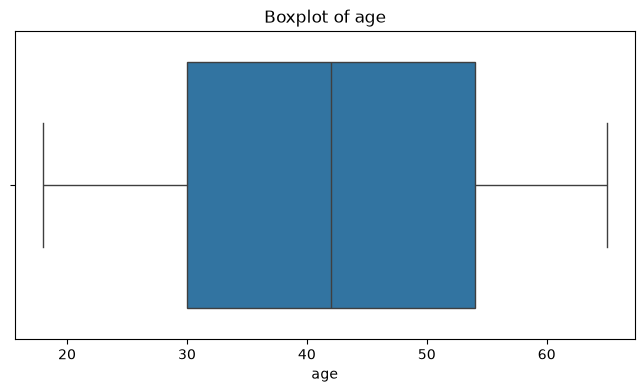

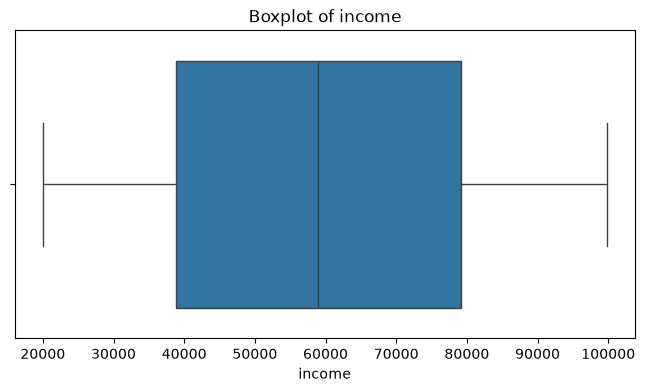

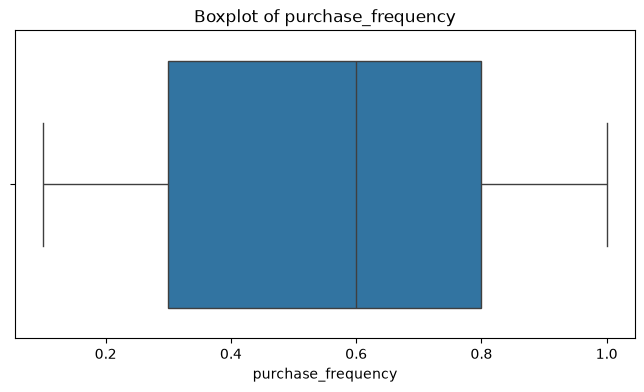

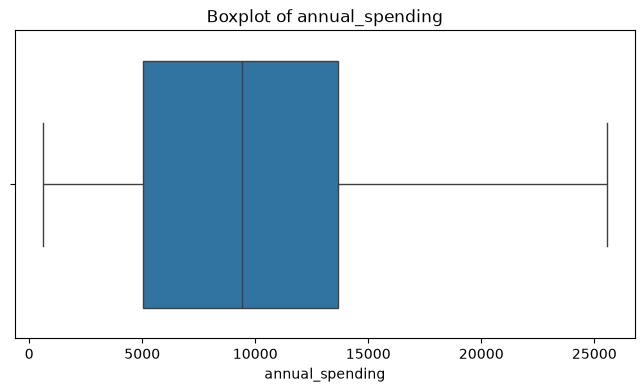

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_columns = [
    "age",
    "income",
    "purchase_frequency",
    "annual_spending"
]

for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.show()

In [12]:
for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    
    print(f"\n{column}")
    print("-" * 40)
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Number of outliers: {len(outliers)}")


age
----------------------------------------
Q1: 30.00
Q3: 54.00
IQR: 24.00
Lower bound: -6.00
Upper bound: 90.00
Number of outliers: 0

income
----------------------------------------
Q1: 38825.50
Q3: 79114.00
IQR: 40288.50
Lower bound: -21607.25
Upper bound: 139546.75
Number of outliers: 0

purchase_frequency
----------------------------------------
Q1: 0.30
Q3: 0.80
IQR: 0.50
Lower bound: -0.45
Upper bound: 1.55
Number of outliers: 0

annual_spending
----------------------------------------
Q1: 5020.43
Q3: 13645.51
IQR: 8625.08
Lower bound: -7917.20
Upper bound: 26583.13
Number of outliers: 0


In [13]:
for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    print(f"{column}: {outlier_count} outliers")

age: 0 outliers
income: 0 outliers
purchase_frequency: 0 outliers
annual_spending: 0 outliers


In [14]:
df_cleaned = df.copy()

df_cleaned.to_csv("../data/customer_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")
print("Shape:", df_cleaned.shape)

Cleaned dataset saved successfully!
Shape: (1000, 8)
